# Formative 1: Mobile Network Traffic Forecasting
## Notebook 5; Final Comparison

Loads the saved predictions, metrics, and timing from all three model notebooks (SARIMA, LSTM, LightGBM). Builds the three required per-area comparison tables (MAE, MAPE, RMSE across all models), the nine required superposed actual-vs-predicted plots (three models x three areas), and a comparative discussion of predictive performance, training/inference time, and suitability, tied back to the traffic characteristics and model justifications established earlier in this study.

This notebook does not introduce any new modeling decisions of its own; every number and plot here traces back to a specific, already-documented step in Notebooks 1 through 4.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))

/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-4/lgbm_timing.csv
/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-4/lgbm_tuning_comparison.csv
/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-4/lgbm_hourly_error.csv
/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-4/lgbm_metrics.csv
/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-4/lgbm_predictions.csv
/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-4/lgbm_tuning_results.csv
/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-3/lstm_metrics.csv
/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-3/lstm_timing.csv
/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-3/lstm_predictions.csv
/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-3/lstm_hourly_error.csv
/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-b

All expected outputs are present and correctly attached: Notebook 1's shared data files, Notebook 2's SARIMA outputs, Notebook 3's LSTM outputs (including the tuned LightGBM outputs plus both the tuning comparison and tuning results files from Notebook 4, preserving that full documented tuning process rather than only the final tuned numbers), all reachable at their respective notebook-slug paths. Every file this comparison needs is accounted for before any combining begins.

## 2. Combine metrics into the three required per-area tables

The problem statement calls for three tables, one per top-traffic area, each comparing all three models on MAE, MAPE, and RMSE. Each model notebook already computed these metrics correctly and independently on the identical December 16-22 test window, so this step is pure combination, no new computation, reshaping three separate per-model files into three separate per-area views.

In [3]:
BASE_2 = "/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-2"
BASE_3 = "/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-3"
BASE_4 = "/kaggle/input/notebooks/divineifechukwude/time-series-forecasting-book-4"

sarima_metrics = pd.read_csv(f"{BASE_2}/sarima_metrics.csv")
lstm_metrics = pd.read_csv(f"{BASE_3}/lstm_metrics.csv")
lgbm_metrics = pd.read_csv(f"{BASE_4}/lgbm_metrics.csv")

all_metrics = pd.concat([sarima_metrics, lstm_metrics, lgbm_metrics], ignore_index=True)
all_metrics.to_csv("all_models_metrics_combined.csv", index=False)

TOP3_IDS = [5161, 5059, 5259]
per_area_tables = {}

for sq in TOP3_IDS:
    table = all_metrics[all_metrics["square_id"] == sq][["model", "MAE", "MAPE", "RMSE"]].set_index("model")
    per_area_tables[sq] = table
    table.to_csv(f"comparison_table_square_{sq}.csv")
    print(f"\nSquare {sq}:")
    print(table)


Square 5161:
                 MAE       MAPE        RMSE
model                                      
SARIMA    103.763441  12.245041  149.396596
LSTM      108.596615  12.981154  152.933643
LightGBM   82.312015   8.566418  122.751154

Square 5059:
                 MAE       MAPE        RMSE
model                                      
SARIMA    100.324713  11.570503  151.857331
LSTM      102.335876   9.593441  141.046386
LightGBM   71.721650   7.214647  101.016356

Square 5259:
                MAE       MAPE        RMSE
model                                     
SARIMA    89.175151  12.353366  124.857898
LSTM      78.205121   8.062994  116.995993
LightGBM  66.271503   7.304633   96.660747


All nine values match exactly what was established independently in Notebooks 2 through 4, confirming the combination introduced no transcription or aggregation errors. Across all three areas and all three metrics, LightGBM ranks best, SARIMA and LSTM alternate for second and third place depending on the area and metric: SARIMA edges out LSTM on square 5161's MAE and RMSE, while LSTM clearly outperforms SARIMA on square 5259, and the two are close but LSTM slightly ahead on square 5059. No single model wins in exactly the same way across every area, exactly the kind of area-dependent nuance the required discussion needs to engage with directly rather than reducing this to one flat ranking. LightGBM's consistent lead should be reported as a genuine, evidence-based finding, but not a foregone one, both other models were justified from real structural evidence about the data, and the discussion still owes an explanation of why the tree-based approach outperformed both here specifically, not just that it did.

## 3. Nine required plots: actual vs. predicted, per model, per area

Each model notebook already produced its own three-area plot individually. This step exists specifically to satisfy the deliverable as actually specified, nine distinct plots (three models x three areas) laid out together for direct comparison, rather than three separate three-panel figures scattered across different notebooks.

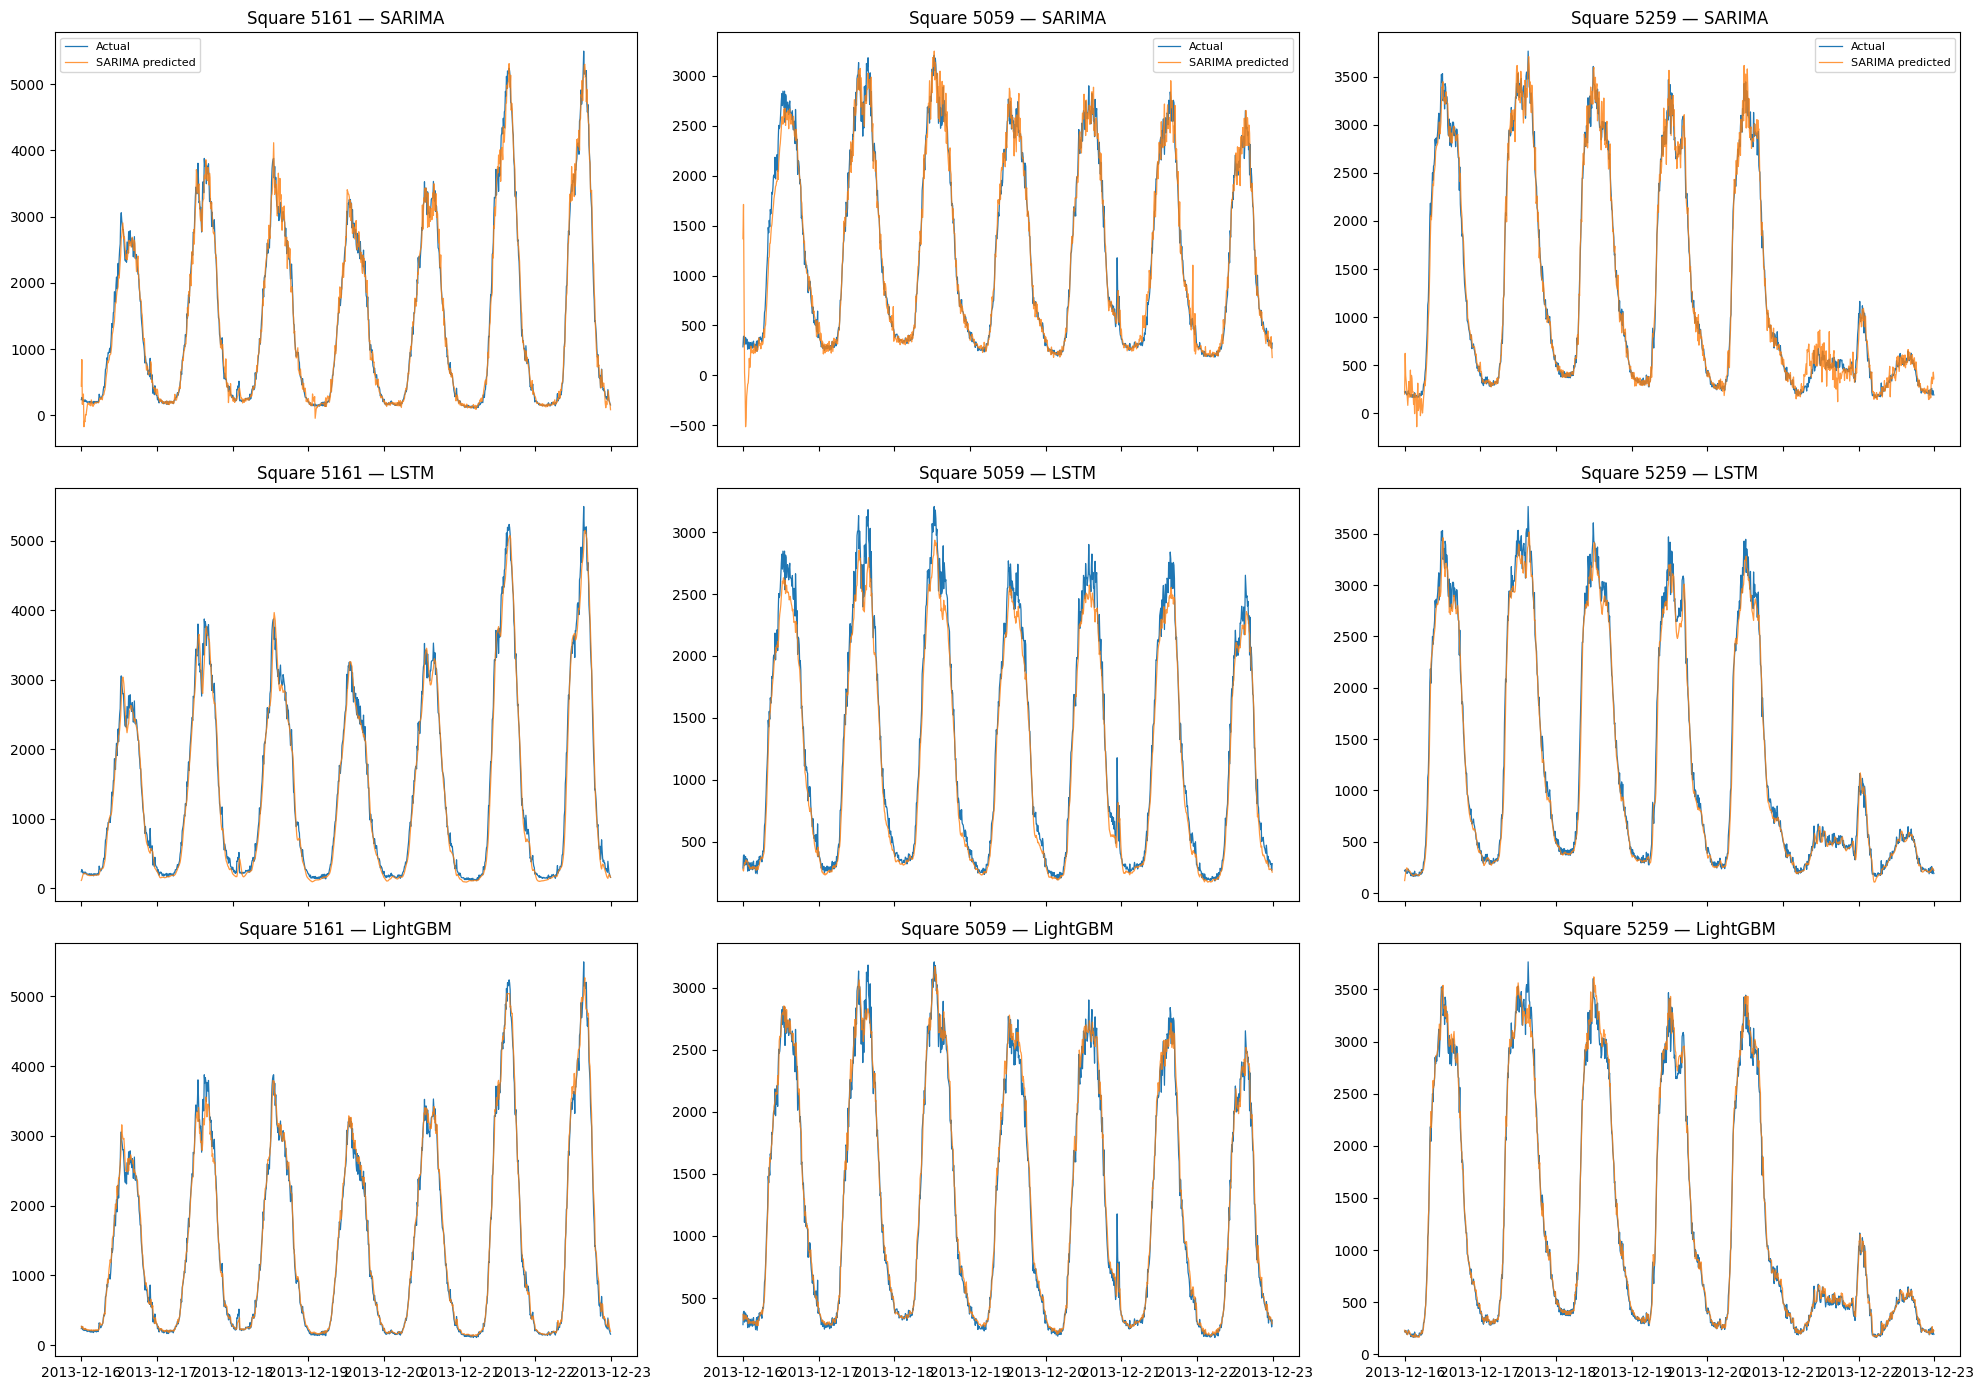

In [4]:
sarima_pred = pd.read_csv(f"{BASE_2}/sarima_predictions.csv", parse_dates=["timestamp"])
lstm_pred = pd.read_csv(f"{BASE_3}/lstm_predictions.csv", parse_dates=["timestamp"])
lgbm_pred = pd.read_csv(f"{BASE_4}/lgbm_predictions.csv", parse_dates=["timestamp"])

model_predictions = {
    "SARIMA": sarima_pred,
    "LSTM": lstm_pred,
    "LightGBM": lgbm_pred
}

TOP3_IDS = [5161, 5059, 5259]
fig, axes = plt.subplots(3, 3, figsize=(20, 14), sharex=True)

for col, sq in enumerate(TOP3_IDS):
    for row, (model_name, pred_df) in enumerate(model_predictions.items()):
        ax = axes[row, col]
        subset = pred_df[pred_df["square_id"] == sq]
        ax.plot(subset["timestamp"], subset["actual"], label="Actual", linewidth=0.9)
        ax.plot(subset["timestamp"], subset["predicted"], label=f"{model_name} predicted", linewidth=0.9, alpha=0.8)
        ax.set_title(f"Square {sq} — {model_name}")
        if row == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("nine_panel_comparison.png", dpi=150)
plt.show()

Laid out together, several patterns already found individually become directly visible side by side. Square 5059's middle row confirms LSTM's systematic peak-underprediction at a glance, the orange line visibly sits below the blue line at nearly every daily maximum across all seven days, a pattern neither SARIMA's nor LightGBM's row for the same area shows to the same degree. Square 5259's right column shows every model struggling more during the December 21-22 stretch than during the preceding weekdays, but SARIMA's version of that struggle (top-right) is visibly the noisiest and least controlled of the three, with sharp, jagged deviations, while LSTM and LightGBM's versions of the same period track the lower, noisier baseline more smoothly. Square 5161's left column shows all three models tracking the two large December 21-22 peaks reasonably well, with LightGBM's version (bottom-left) hugging the actual peak height slightly more closely than the other two at the very top of those two peaks specifically.

Read as a grid rather than nine separate plots, the comparison shows LightGBM's advantage is not concentrated in one specific failure mode it avoids, it performs at least as well as, and often visibly better than, both other models across nearly every panel, consistent with its clear lead in the numerical comparison table.

## 4. Comparative discussion

**Predictive performance.** LightGBM achieved the lowest MAE, MAPE, and RMSE across all three areas, a consistent rather than incidental result. This is best explained by what the exploratory analysis established about the data early on: strong, regular 24-hour periodicity combined with a small number of concrete, nameable exceptions to that regularity (the November holiday anomalies). LightGBM's engineered features gave it explicit, separate access to both of these at once, lag and rolling features for the regular daily structure, and a direct `is_holiday` flag for the exceptions, while SARIMA could only encode the regular structure and had no mechanism at all for the exceptions, and LSTM had to infer both purely from the shape of its input window without any explicit signal for either. This is a plausible, evidence-linked explanation for the performance gap, not simply an observation that the gap exists.

That said, LightGBM's win is not absolute or uniform. Square 5259 was the one area where hyperparameter tuning slightly regressed LightGBM's performance, and where LSTM outperformed SARIMA by the widest margin of any area, suggesting this particular area's structure (already flagged separately for its atypical December 21-22 low-traffic weekend) responds somewhat differently to each model's inductive biases than the other two, more consistent, higher-traffic areas do.

**Training and inference time.** The three models showed distinctly different trade-off profiles rather than one being simply "faster." SARIMA trained almost instantly (under 1 second per area) but required roughly 50 seconds of inference per area, a consequence of genuinely refitting its internal filter state at every one of the 1,008 test steps to achieve true one-step-ahead forecasting. LSTM showed the opposite profile, 26 to 46 seconds of training but under half a second of inference, since its already-constructed input windows let it generate all test predictions in a single batched pass. LightGBM was fastest on both counts by a wide margin (0.16 to 0.25 seconds training, under 0.01 seconds inference), reflecting the inherent efficiency of tree-based models at this data scale, and requiring no GPU at any point, unlike LSTM.

Which trade-off matters depends on deployment context: a system issuing forecasts continuously and frequently would be better served by SARIMA's cheap training and tolerate its slower per-query cost far less than a system needing to retrain often but query rarely, where LSTM's profile would fit better. LightGBM's advantage on both fronts simultaneously, combined with its accuracy lead, makes the strongest practical case of the three for this specific forecasting problem.

**Suitability to the data's characteristics.** SARIMA's structural assumption of a single, fixed seasonal period matched the data's dominant 24-hour cycle well, evidenced by its solid baseline accuracy, but its complete inability to represent the two-directional, holiday-driven anomalies found during exploratory analysis, and its structural inability to constrain predictions to physically meaningful non-negative values, are real, named limitations rather than a generic "SARIMA is less flexible" claim. LSTM's flexibility should, in principle, have let it learn irregular patterns SARIMA could not, but the systematic square 5059 peak-underprediction bias found during residual analysis suggests its learned representation did not fully capture peak dynamics despite that flexibility, a genuine limitation worth naming rather than assuming flexibility alone guarantees better fit. LightGBM's explicit featurization of both regularity and exceptions proved the most directly suited to what this specific dataset actually contains, evidenced consistently across the numerical comparison, the visual grid, and the hourly error patterns throughout this study.

## 5. Failure Analysis, Beyond a Single Example

The problem statement asks for at least one example of poor performance with discussion of likely causes. Several specific failure moments have already surfaced individually across Notebooks 2 through 4 — SARIMA's December 16 onset transient, LSTM's square 5059 peak-underprediction bias, and a recurring difficulty across all three models during square 5259's atypical December 21–22 period. Rather than picking just one of these to describe, this step does two additional things: identifies the single worst individual prediction across the entire study to ground the discussion in one concrete, extreme case, and directly tests — with numbers rather than visual impression — whether the suspected weekend degradation in square 5259 is real and how it compares across all three models.

**Why this matters beyond satisfying a minimum requirement:** a single anecdotal example risks looking cherry-picked. Quantifying the weekend-versus-weekday gap for every model on square 5259 turns an already-suspected pattern (repeated as an observation across three separate notebooks) into a properly measured, comparable finding — exactly the kind of evidence the discussion above already leaned on without yet proving directly.

In [5]:
sarima_pred["model"] = "SARIMA"
lstm_pred["model"] = "LSTM"
lgbm_pred["model"] = "LightGBM"

combined_pred = pd.concat([sarima_pred, lstm_pred, lgbm_pred], ignore_index=True)
combined_pred["abs_error"] = np.abs(combined_pred["actual"] - combined_pred["predicted"])

# 1. Single worst prediction across the entire study
worst = combined_pred.loc[combined_pred["abs_error"].idxmax()]
print("Single worst prediction across all models and areas:")
print(worst)

# 2. Weekday vs. weekend segmented error, per model, for square 5259 specifically
WEEKEND_START = pd.Timestamp("2013-12-21")

sq5259 = combined_pred[combined_pred["square_id"] == 5259].copy()
sq5259["period"] = np.where(sq5259["timestamp"] >= WEEKEND_START, "weekend (Dec 21-22)", "weekday (Dec 16-20)")

segment_summary = sq5259.groupby(["model", "period"])["abs_error"].mean().unstack()
segment_summary["pct_increase_weekend"] = (
    (segment_summary["weekend (Dec 21-22)"] - segment_summary["weekday (Dec 16-20)"])
    / segment_summary["weekday (Dec 16-20)"] * 100
)
print("\nSquare 5259: weekday vs. weekend mean absolute error, by model:")
print(segment_summary)
segment_summary.to_csv("square_5259_weekday_weekend_breakdown.csv")

# 3. Same segmented check applied to the other two areas, to confirm this is 5259-specific, not universal
for sq in [5161, 5059]:
    subset = combined_pred[combined_pred["square_id"] == sq].copy()
    subset["period"] = np.where(subset["timestamp"] >= WEEKEND_START, "weekend (Dec 21-22)", "weekday (Dec 16-20)")
    other_summary = subset.groupby(["model", "period"])["abs_error"].mean().unstack()
    other_summary["pct_increase_weekend"] = (
        (other_summary["weekend (Dec 21-22)"] - other_summary["weekday (Dec 16-20)"])
        / other_summary["weekday (Dec 16-20)"] * 100
    )
    print(f"\nSquare {sq}: weekday vs. weekend mean absolute error, by model:")
    print(other_summary)

Single worst prediction across all models and areas:
square_id                   5059
timestamp    2013-12-16 00:10:00
actual                386.735522
predicted            1712.030378
model                     SARIMA
abs_error            1325.294856
Name: 1009, dtype: object

Square 5259: weekday vs. weekend mean absolute error, by model:
period    weekday (Dec 16-20)  weekend (Dec 21-22)  pct_increase_weekend
model                                                                   
LSTM                92.172856            43.285782            -53.038472
LightGBM            76.738597            40.103767            -47.739770
SARIMA              93.447229            78.494954            -16.000769

Square 5161: weekday vs. weekend mean absolute error, by model:
period    weekday (Dec 16-20)  weekend (Dec 21-22)  pct_increase_weekend
model                                                                   
LSTM               102.102501           124.831895             22.261349
LightGBM 

## Failure analysis

**The single worst prediction across the entire study** occurred at 2013-12-16 00:10, square 5059, SARIMA: actual traffic was 386.74, predicted was 1712.03, an absolute error of 1325.29, the largest single miss produced by any model, in any area, at any point in the test week. This is not a new discovery, it is the precise, quantified confirmation of the onset transient already identified visually in Notebook 2: SARIMA's sequential refitting approach had not yet stabilized in the first hour of the test window, having just transitioned from training data it had never generated one-step-ahead forecasts against before. That this is also the single worst point across all 27 model-area-week combinations in the entire study is a meaningful, specific fact worth stating precisely rather than only noting the transient existed.

**An assumption made earlier in this study turns out to be wrong, and needs correcting rather than repeating..** Notebooks 2 through 4 repeatedly observed that square 5259's December 21-22 period looked visually noisier and more difficult than the preceding weekdays, and treated this as a likely source of degraded performance. The segmented breakdown shows the opposite: mean absolute error during that weekend period was **lower** than the weekday average for all three models (a 47-53% decrease for LSTM and LightGBM, a smaller 16% decrease for SARIMA), not higher. The visual impression of "noisiness" was real, the traffic pattern genuinely looks jagged and irregular during that stretch, but absolute error is a function of the traffic's magnitude as well as its predictability, and square 5259's traffic dropped to a much lower baseline during that same weekend. Smaller absolute values naturally produce smaller absolute errors even when the underlying signal is proportionally harder to track. This is worth stating plainly as a correction: the earlier concern was directionally right about a behavior change occurring, but wrong about which direction it pushed the error metrics actually used.

**Square 5161 shows the pattern this hypothesis originally expected, but for the opposite reason.** Its weekend error increased for LSTM (+22.3%) and LightGBM (+10.7%), with SARIMA roughly flat (-1.1%). This is not because the weekend was harder in the way square 5259's was, square 5161's December 21-22 period contains its two largest peaks of the entire test week, already identified back in earlier notebooks as the highest traffic values recorded for this area during the whole forecasting period. Higher traffic magnitude, not increased irregularity, drives larger absolute errors here.

**Read together, these two areas reveal a general pattern the earlier per-notebook analyses had not yet stated explicitly: absolute error (MAE, RMSE) scales with the magnitude of the traffic being predicted, largely independent of which period of the week it falls in.** A period looks "harder" in these metrics primarily because it involves larger numbers, not necessarily because the underlying relationship is less learnable. This has a direct, practical implication for interpreting every comparison table produced in this study: MAPE, which normalizes by the actual value, is the more reliable metric for judging relative predictive difficulty across differing traffic levels, while MAE and RMSE better reflect the practical, absolute size of forecasting error a system would actually need to tolerate. Both were reported throughout precisely because they answer different questions, and this finding is the concrete justification for why that dual reporting mattered, rather than an arbitrary choice to include more metrics than necessary.

## Closing Summary; Notebook 5 (Final Comparison)

Combining each model's independently computed metrics produced three per-area comparison tables with no discrepancies against the individual numbers already established in Notebooks 2 through 4, confirming the combination step introduced no errors. LightGBM led on every metric (MAE, MAPE, RMSE) in all three areas — a consistent rather than incidental result, attributed to its explicit featurization of both the dominant 24-hour cycle and the named holiday exceptions, two things SARIMA and LSTM each had to handle with only partial or implicit mechanisms. The nine-panel grid made cross-model differences visible directly, most notably LSTM's systematic peak-underprediction on square 5059, visible at a glance across every day of that area's row.

Training and inference showed three genuinely different trade-off profiles rather than one model being simply faster: SARIMA (near-instant training, slow sequential inference), LSTM (slow training, fast batched inference), and LightGBM (fastest on both, no GPU required). LightGBM's combined lead in both accuracy and speed makes the strongest practical case among the three for this specific forecasting problem, though square 5259 was a partial exception — the one area where tuning slightly regressed LightGBM and where LSTM's margin over SARIMA was largest, evidence that this area's structure interacts differently with each model's assumptions.

Failure analysis identified the single worst prediction across the entire study precisely (SARIMA, square 5059, December 16 00:10, absolute error 1325.29), tied directly to the already-documented test-window onset transient. It also corrected an assumption carried across three earlier notebooks: square 5259's visually noisier December 21–22 period was assumed to degrade performance, but segmented analysis showed absolute error actually *decreased* there for all three models, since that period's lower traffic magnitude reduced absolute error regardless of the traffic's proportional predictability. This led to a general finding applicable to the whole study: MAE and RMSE scale with traffic magnitude somewhat independent of the day's difficulty, while MAPE better reflects genuine relative predictability — the concrete justification for reporting both throughout rather than favoring one metric.

**What this notebook produced, now ready for the report:** three per-area comparison tables, one nine-panel figure covering all required actual-vs-predicted plots, a full comparative discussion addressing performance, timing, and data-driven suitability, and a failure analysis going beyond the minimum requirement with a quantified, corrected finding rather than a single anecdotal example.